In [1]:
!python3 --version
!python3 -m pip install tensorflow pandas numpy scikit-learn matplotlib

Python 3.13.12
Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical
from keras.optimizers import Adam

In [3]:
train = "final.csv"
test = "test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

In [4]:
X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)

In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [7]:

def build_cnn(input_shape, num_classes):
    model = Sequential([
        
        Conv1D(64, kernel_size=3, padding="same", activation="relu", input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        
        Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        
        Conv1D(256, kernel_size=3, padding="same", activation="relu"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Replace Flatten with GAP
        GlobalAveragePooling1D(),

        # Dense head
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

fold_accuracies = []
histories = []

fold = 1
for train_idx, val_idx in skf.split(X, y_encoded):
    print(f"\nFold {fold}/10")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    y_train_cat = to_categorical(y_train, num_classes)
    y_val_cat = to_categorical(y_val, num_classes)

    model = build_cnn(
        input_shape=(X.shape[1], 1),
        num_classes=num_classes
    )

    history = model.fit(
        X_train,
        y_train_cat,
        epochs=50,
        batch_size=256,
        validation_data=(X_val, y_val_cat),
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
    fold_accuracies.append(val_acc)
    histories.append(history)

    print(f"Fold {fold} Validation Accuracy: {val_acc:.4f}")
    fold += 1


Fold 1/10
Epoch 1/50


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7422 - loss: 0.6401 - val_accuracy: 0.6150 - val_loss: 0.9268
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8305 - loss: 0.4111 - val_accuracy: 0.6793 - val_loss: 1.0328
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8509 - loss: 0.3607 - val_accuracy: 0.9195 - val_loss: 0.2521
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8595 - loss: 0.3423 - val_accuracy: 0.6198 - val_loss: 1.0814
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8695 - loss: 0.3256 - val_accuracy: 0.7577 - val_loss: 0.4656
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8736 - loss: 0.3128 - val_accuracy: 0.7320 - val_loss: 0.7551
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8808 - loss: 0.3011 - val_accuracy: 0.6913 - val_loss: 1.1170
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8861 - loss: 0.2901 - val_accuracy: 0.725

In [9]:
print("\nCross-Validation Results")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Std Dev: {np.std(fold_accuracies):.4f}")


Cross-Validation Results
Mean Accuracy: 0.8199
Std Dev: 0.0548


In [10]:
y_cat = to_categorical(y_encoded, num_classes)

final_model = build_cnn(
    input_shape=(X.shape[1], 1),
    num_classes=num_classes
)

final_history = final_model.fit(
    X,
    y_cat,
    epochs=50,
    batch_size=256,
    verbose=1
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7579 - loss: 0.5929
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8351 - loss: 0.3994
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8590 - loss: 0.3466
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8671 - loss: 0.3268
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8803 - loss: 0.2991
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8870 - loss: 0.2881
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8927 - loss: 0.2743
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8962 - loss: 0.2659
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8992 - loss: 0.2578
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8777 - loss: 0.3104
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8942 - loss: 0.2703
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 

In [11]:
y_test_cat = to_categorical(y_test_encoded, num_classes)

test_loss, test_acc = final_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nBest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Best Accuracy: 0.9550
Test Loss: 1.0043


581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1200x1200 with 0 Axes>

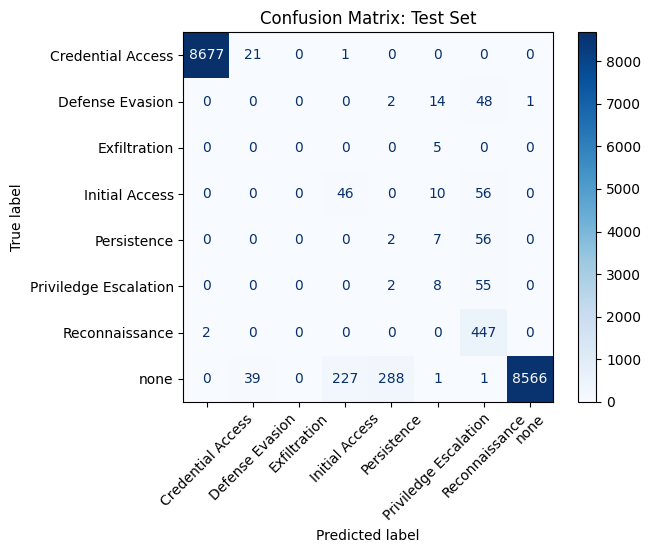

In [12]:
y_test_pred = np.argmax(final_model.predict(X_test), axis=1)

cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix: Test Set")
plt.show()

581/581 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report
                       precision    recall  f1-score   support

    Credential Access       1.00      1.00      1.00      8699
      Defense Evasion       0.00      0.00      0.00        65
         Exfiltration       0.00      0.00      0.00         5
       Initial Access       0.17      0.41      0.24       112
          Persistence       0.01      0.03      0.01        65
Priviledge Escalation       0.18      0.12      0.15        65
       Reconnaissance       0.67      1.00      0.80       449
                 none       1.00      0.94      0.97      9122

             accuracy                           0.96     18582
            macro avg       0.38      0.44      0.40     18582
         weighted avg       0.98      0.96      0.96     18582



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

<Figure size 1200x1200 with 0 Axes>

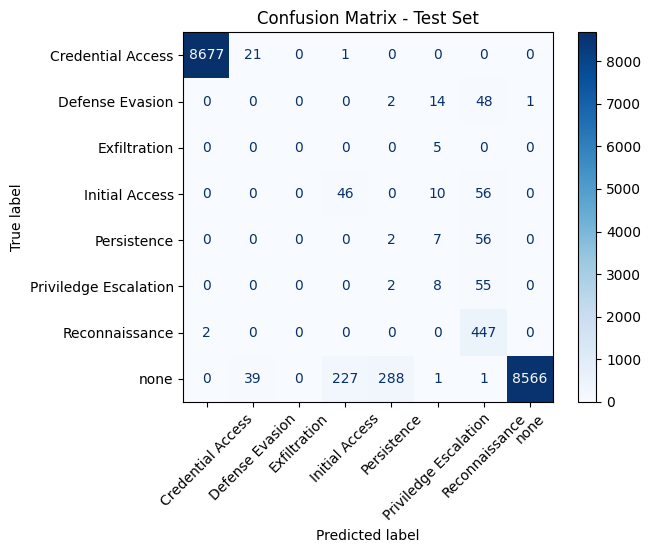


False Positive Rate (per class)
Credential Access: 0.0002
Defense Evasion: 0.0032
Exfiltration: 0.0000
Initial Access: 0.0123
Persistence: 0.0158
Priviledge Escalation: 0.0020
Reconnaissance: 0.0119
none: 0.0001

Average FPR: 0.005696515554160845


In [13]:

y_test_pred = np.argmax(final_model.predict(X_test), axis=1)


print("\nClassification Report")
print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)


cm = confusion_matrix(y_test_encoded, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(12, 12))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - Test Set")
plt.show()


print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))

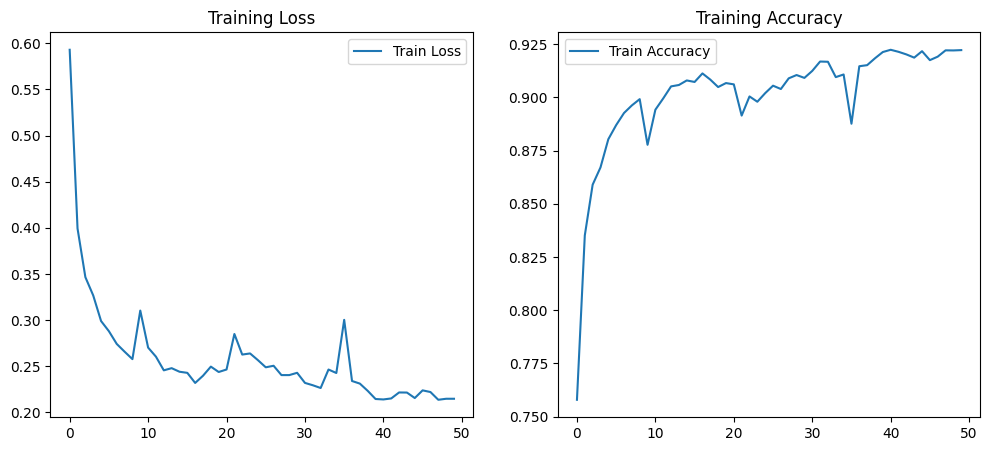

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(final_history.history["loss"], label="Train Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(final_history.history["accuracy"], label="Train Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()